# Unsupervised learning. Clustering

## Task 1.
1) Propose a new method to initialize cluster centroids for K-means. List the advantages and disadvantages of Forgy, Random Partition, and your own initializations.

    ### Cluster Centroid Initialization for K-means

    | Method | How it works | Advantages | Disadvantages |
    |---|---|---|---|
    | **Forgy** | Randomly pick K actual data<br> points as initial centroids | Simple, fast; centroids start<br> as real data points | Centroids can end up close<br> together (same dense<br> region); high sensitivity to<br> random seed; poor coverage<br> of true clusters |
    | **Random Partition** | Randomly assign every<br> point to one of K clusters,<br> then compute each cluster's<br> mean as the initial centroid | Centroids start near the<br> global data center, avoiding<br> extreme outliers; simple | All centroids start close to<br> the global mean → close to<br> each other → slow<br> convergence; ignores actual<br> data distribution |
    | **K-means++ (proposed)** | Pick first centroid randomly;<br> each next centroid is chosen<br> with probability<br> proportional to its squared<br> distance from the nearest<br> already-chosen centroid | Spreads centroids apart by<br> design; provable O(log k)<br> approximation guarantee;<br> faster convergence, more<br> consistent results | More expensive init<br> - distance computations; still<br> probabilistic; sensitive to<br> outliers (may "waste" a<br> centroid on a noise point) |

2) Describe how you can use clustering to speed up the KNN model. Hint: what is kd-tree?

    Standard KNN stores the entire training set and, for every new query point, computes the distance to *all* N training points to find the K nearest ones.

    Instead of comparing a query point to every single training point, we can first group the training data into clusters (e.g., using K-means) and use that structure to **narrow down the search space**

  
    A **kd-tree** (k-dimensional tree) is a data structure that generalizes this same idea in a more structured, hierarchical way:
    - It recursively partitions the feature space along different dimensions (splitting on the median value of one feature at each level), building a binary tree.
    - Searching for nearest neighbors means traversing the tree from the root, quickly eliminating whole branches (subspaces) that can't contain a closer point than the current best candidate, thanks to the triangle inequality.

## Task 2. Introduction: make all the preprocessing personnel from the previous lesson.


In [1]:
import pandas as pd
import numpy as np
from matplotlib import pyplot as plt

from collections import Counter

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import PolynomialFeatures, MinMaxScaler
from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, mean_absolute_percentage_error, r2_score, silhouette_score
import sklearn.cluster as cluster
from sklearn.mixture import GaussianMixture

from scipy.spatial.distance import cdist

In [2]:
import time
timing_results = []

In [3]:
train = pd.read_csv('data/train.csv')
test = pd.read_csv('data/test.csv')

### outliers

In [4]:
low_train, high_train = np.percentile(train['price'], [1, 99])
low_test, high_test = np.percentile(test['price'], [1, 99])

train = train[(train['price'] >= low_train) & (train['price'] <= high_train)]
test = test[(test['price'] >= low_test) & (test['price'] <= high_test)]

low_bath, high_bath = np.percentile(test['bathrooms'], [1, 99])
test = test[(test['bathrooms'] >= low_bath) & (test['bathrooms'] <= high_bath)]

### get features

In [5]:
train.features = train.features.apply(lambda x: x.replace('"', '').replace('[', '').replace(']', '').replace("'", '').replace(' ', ''))
test.features = test.features.apply(lambda x: x.replace('"', '').replace('[', '').replace(']', '').replace("'", '').replace(' ', ''))


features_list = []

for _, row in train.iterrows():
  curr = row.features.split(',')
  if curr != ['']:
    features_list.extend(curr)

In [6]:
counter = Counter(features_list)

features = counter.most_common(20)
xtrain = pd.DataFrame()
xtest = pd.DataFrame()

for f in features:
  xtrain[f[0]] = train.features.apply(lambda x: int(f[0] in x.split(',')))
  xtest[f[0]] = test.features.apply(lambda x: int(f[0] in x.split(',')))


xtrain['bathrooms'], xtest['bathrooms'] = train.bathrooms, test.bathrooms
xtrain['bedrooms'], xtest['bedrooms']  = train.bedrooms, test.bathrooms
xtrain['interest_level'], xtest['interest_level']  = train.interest_level, test.interest_level

train_feature_list = xtrain.columns
test_feature_list = xtest.columns

In [7]:
ytrain = train['price']
ytest = test['price']

## Task 3. Implement the next method.

### K-means algorithm

In [8]:
class Kmeans:
  def __init__(self, n_clusters=8, max_iter=100, tol=0.00001,  random_state=None):
    self.n_clusters = n_clusters
    self.max_iter = max_iter
    self.random_state = random_state
    self.tol = tol
    self.labels_ = None
    self.cluster_centers_ = None

  def _init_centroids_plus_plus(self, X: np.ndarray):
    n_samples = X.shape[0]
    centers = [X[np.random.choice(n_samples)]]
    for _ in range(1, self.n_clusters):
        dist_sq = np.min(
            [np.sum((X - c) ** 2, axis=1) for c in centers],
            axis=0
        )

        probs = dist_sq / dist_sq.sum()
        next_idx = np.random.choice(n_samples, p=probs)
        centers.append(X[next_idx])

    return np.array(centers)

  def fit(self, X: np.ndarray):
    X = np.asarray(X)

    if self.random_state:
      np.random.seed(self.random_state)
    self.cluster_centers_ = self._init_centroids_plus_plus(X)

    for i in range(self.max_iter):
      self.labels_ = self._assign_clusters(X)

      centers = self._compute_centers(X)

      if np.max(np.linalg.norm(centers - self.cluster_centers_, axis=1)) < self.tol:
        break

      self.cluster_centers_ = centers

  def _assign_clusters(self, X: np.ndarray):
    labels = []

    for x in X:
      distances = [0] * self.n_clusters
      for j in range(self.n_clusters):
        distances[j] = np.linalg.norm(x - self.cluster_centers_[j])

      labels.append(np.argmin(distances))

    return labels

  def _compute_centers(self, X: np.ndarray):
    if self.random_state:
      np.random.seed(self.random_state)

    new_centers = []
    labels = np.array(self.labels_)

    for i in range(self.n_clusters):
      points = X[labels == i]

      if len(points) > 0:
        new_center = np.mean(points, axis=0)
      else:
        new_center = X[np.random.choice(X.shape[0])]

      new_centers.append(new_center)

    return np.array(new_centers)

  def predict(self, X: np.ndarray):
    X = np.asarray(X)

    return self._assign_clusters(X)

### Clustering

In [9]:
kmeans = Kmeans(n_clusters=30, random_state=21)

_start = time.perf_counter()
kmeans.fit(train[['latitude', 'longitude']])
_elapsed = time.perf_counter() - _start
timing_results.append({'algorithm': 'KMeans Lasso', 'n_samples': train.shape[0], 'time_sec': _elapsed})
print(f'CKMeans Lasso fit time: {_elapsed:.4f} sec')

CKMeans Lasso fit time: 74.7688 sec


In [ ]:
xtrain['cluster_label'] = kmeans.predict(train[['latitude', 'longitude']])
xtest['cluster_label'] = kmeans.predict(test[['latitude', 'longitude']])

### Silhouette score and Distortion.

In [ ]:
print(f"Silhouette score: {silhouette_score(train[['latitude', 'longitude']], xtrain['cluster_label'])}")

Silhouette score: 0.4772439611538567


In [ ]:
centroids = kmeans.cluster_centers_

distances = cdist(train[['latitude', 'longitude']], centroids, 'euclidean')

min_distances = np.min(distances, axis=1)

distortion = np.sum(min_distances ** 2)

print(f"Distortion: {distortion}")

Distortion: 4.77278288482144


### Scatter plot

[(40.65, 40.85)]

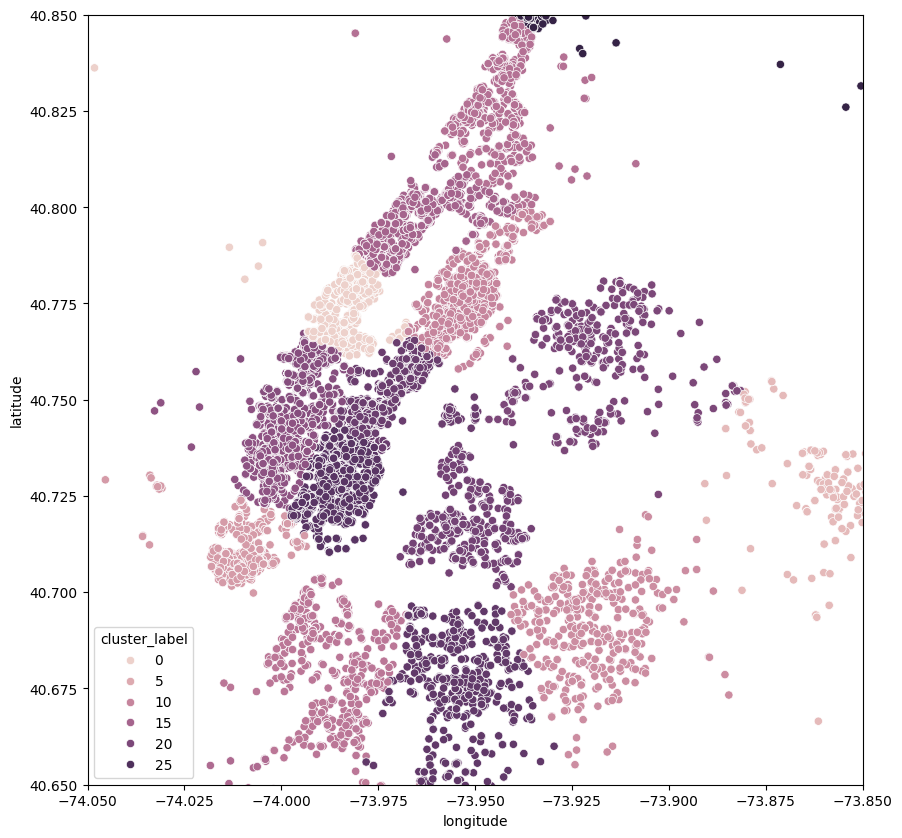

In [ ]:
import seaborn as sns
fig = plt.figure(figsize=(10, 10))
g = sns.scatterplot(
    x=train['longitude'],
    y=train['latitude'],
    hue=xtrain['cluster_label']
)
g.set(xlim=(-74.05,-73.85))
g.set(ylim=(40.65,40.85))

[(40.65, 40.85)]

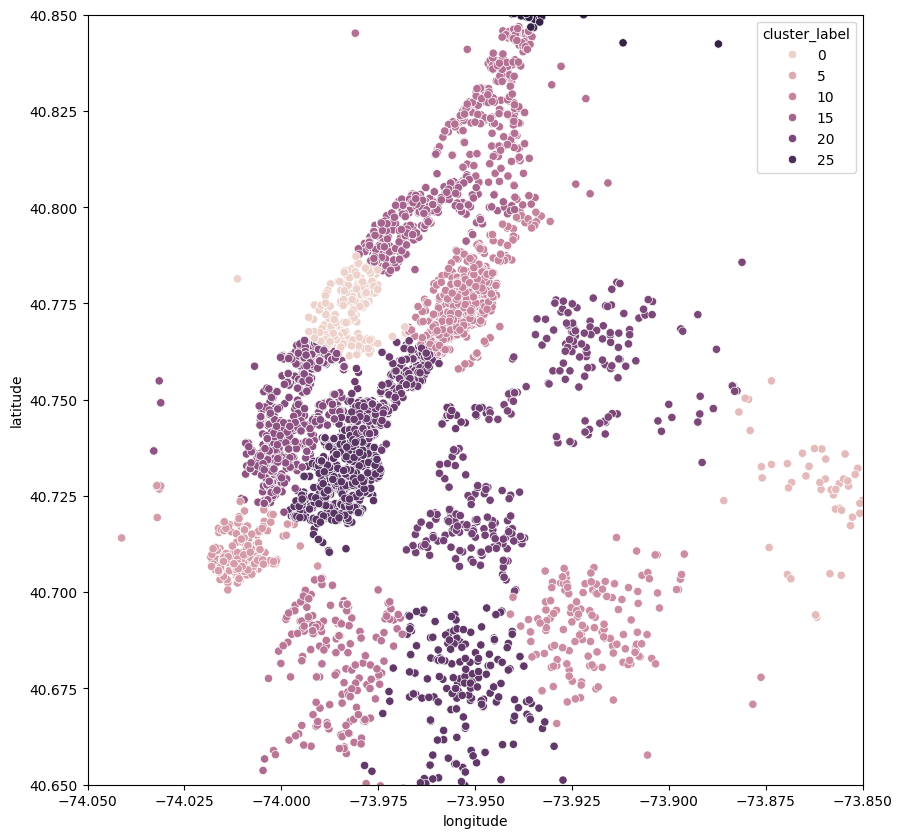

In [ ]:
import seaborn as sns
fig = plt.figure(figsize=(10, 10))
g = sns.scatterplot(
    x=test['longitude'],
    y=test['latitude'],
    hue=xtest['cluster_label']
)
g.set(xlim=(-74.05,-73.85))
g.set(ylim=(40.65,40.85))

### Lasso Regression

In [ ]:
def fit_lasso_and_get_feature_importance(xtrain, ytrain, xtest):
  scaler = MinMaxScaler()
  xtrain_norm = pd.DataFrame(scaler.fit_transform(xtrain))
  xtest_norm = pd.DataFrame(scaler.transform(xtest))

  lasso_model = Lasso(random_state=21)

  lasso_model.fit(xtrain_norm, ytrain)

  feature_importance = pd.DataFrame()
  feature_importance['name'] = xtrain.columns
  feature_importance['imp'] = abs(lasso_model.coef_)
  feature_importance = feature_importance.sort_values('imp')

  return lasso_model, feature_importance, xtrain_norm, xtest_norm

In [ ]:
def get_metrics(lasso_model, xtrain, ytrain, xtest, ytest, model_name):
  score_train=lasso_model.predict(xtrain)
  score_test=lasso_model.predict(xtest)

  result_MAE = {'model' : model_name,
                   'train' : mean_absolute_error(ytrain, score_train),
                   'test' :  mean_absolute_error(ytest, score_test)
                  }


  result_RMSE = {'model' : model_name,
                    'train' : mean_squared_error(ytrain, score_train)**0.5,
                    'test' :  mean_squared_error(ytest, score_test)**0.5
                    }

  result_r2 = {'model' : model_name,
                    'train' : r2_score(ytrain, score_train),
                    'test' :  r2_score(ytest, score_test)
                    }
  return result_MAE, result_RMSE, result_r2


In [ ]:
scaler = MinMaxScaler()
xtrain_norm = pd.DataFrame(scaler.fit_transform(xtrain))
xtest_norm = pd.DataFrame(scaler.transform(xtest))

lasso_model = Lasso(random_state=21)

lasso_model.fit(xtrain_norm, ytrain)

Lasso(random_state=21)

### Feature importance

In [ ]:
feature_importance = pd.DataFrame()
feature_importance['name'] = xtrain.columns
feature_importance['imp'] = abs(lasso_model.coef_)
feature_importance = feature_importance.sort_values('imp')
feature_importance

,name,imp
2,CatsAllowed,0.000000
15,Balcony,0.000000
12,OutdoorSpace,14.748589
16,SwimmingPool,37.111254
9,Pre-War,51.187086
11,RoofDeck,69.299349
3,DogsAllowed,76.024551
6,NoFee,77.264467
19,Terrace,79.407228
18,NewConstruction,80.036631


### Accuracy results

In [ ]:
result_MAE = []
result_RMSE = []
result_r2 = []

score_train=lasso_model.predict(xtrain_norm)
score_test=lasso_model.predict(xtest_norm)

result_MAE.append({'model' : 'KMeans Lasso',
                   'train' : mean_absolute_error(ytrain, score_train),
                   'test' :  mean_absolute_error(ytest, score_test)
                  })


result_RMSE.append({'model' : 'KMeans Lasso',
                   'train' : mean_squared_error(ytrain, score_train)**0.5,
                   'test' :  mean_squared_error(ytest, score_test)**0.5
                  })

result_r2.append({'model' : 'KMeans Lasso',
                   'train' : r2_score(ytrain, score_train),
                   'test' :  r2_score(ytest, score_test)
                  })

display(pd.DataFrame(result_MAE))
display(pd.DataFrame(result_RMSE))
display(pd.DataFrame(result_r2))

,model,train,test
0,KMeans Lasso,646.901236,706.167728


,model,train,test
0,KMeans Lasso,905.754951,965.135392


,model,train,test
0,KMeans Lasso,0.594903,0.457838


### Sklearn K-Means

In [10]:
sklearn_kmeans = cluster.KMeans(n_clusters=30, random_state=21)
_start = time.perf_counter()
sklearn_kmeans.fit(train[['latitude', 'longitude']])
_elapsed = time.perf_counter() - _start
timing_results.append({'algorithm': 'Sklearn KMeans (lat/long)', 'n_samples': train.shape[0], 'time_sec': _elapsed})
print(f"Sklearn KMeans fit time: {_elapsed:.4f} sec")

Sklearn KMeans fit time: 0.1189 sec


In [ ]:
silhouette_score(train[['latitude', 'longitude']], sklearn_kmeans.predict(train[['latitude', 'longitude']]))

np.float64(0.43505788814249685)

In [ ]:
distortion = sklearn_kmeans.inertia_

print(f"Distortion: {distortion}")

Distortion: 4.700265364177531


In [ ]:
xtrain['cluster_label'] = sklearn_kmeans.predict(train[['latitude', 'longitude']])
xtest['cluster_label'] = sklearn_kmeans.predict(test[['latitude', 'longitude']])

[(40.65, 40.85)]

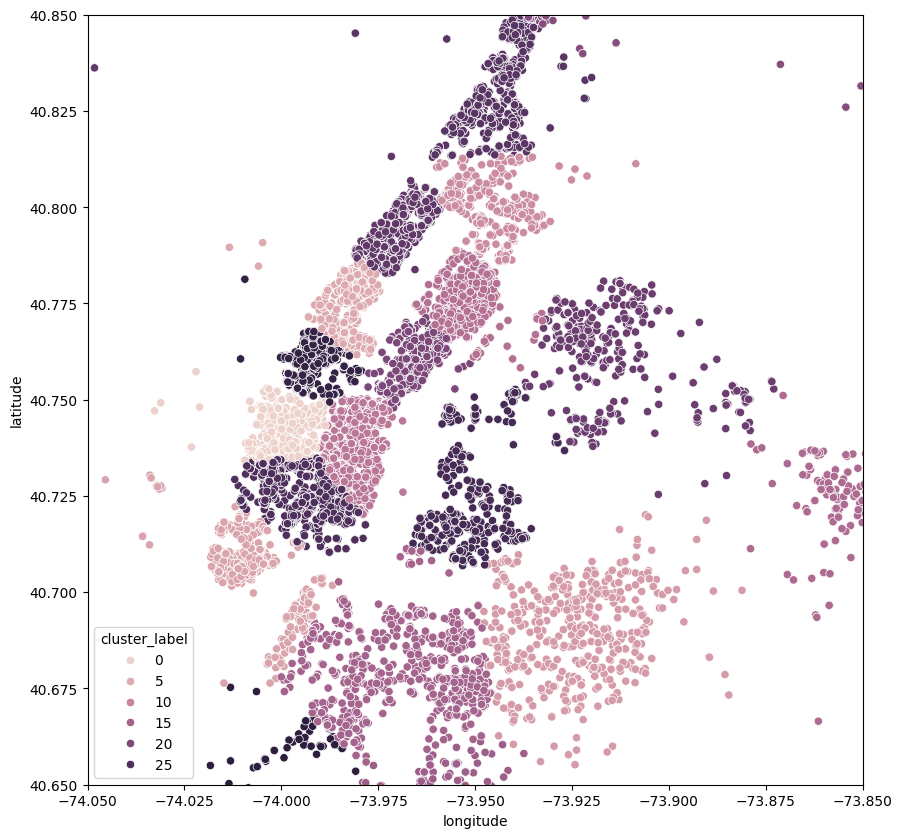

In [ ]:
import seaborn as sns
fig = plt.figure(figsize=(10, 10))
g = sns.scatterplot(
    x=train['longitude'],
    y=train['latitude'],
    hue=xtrain['cluster_label']
)
g.set(xlim=(-74.05,-73.85))
g.set(ylim=(40.65,40.85))

[(40.65, 40.85)]

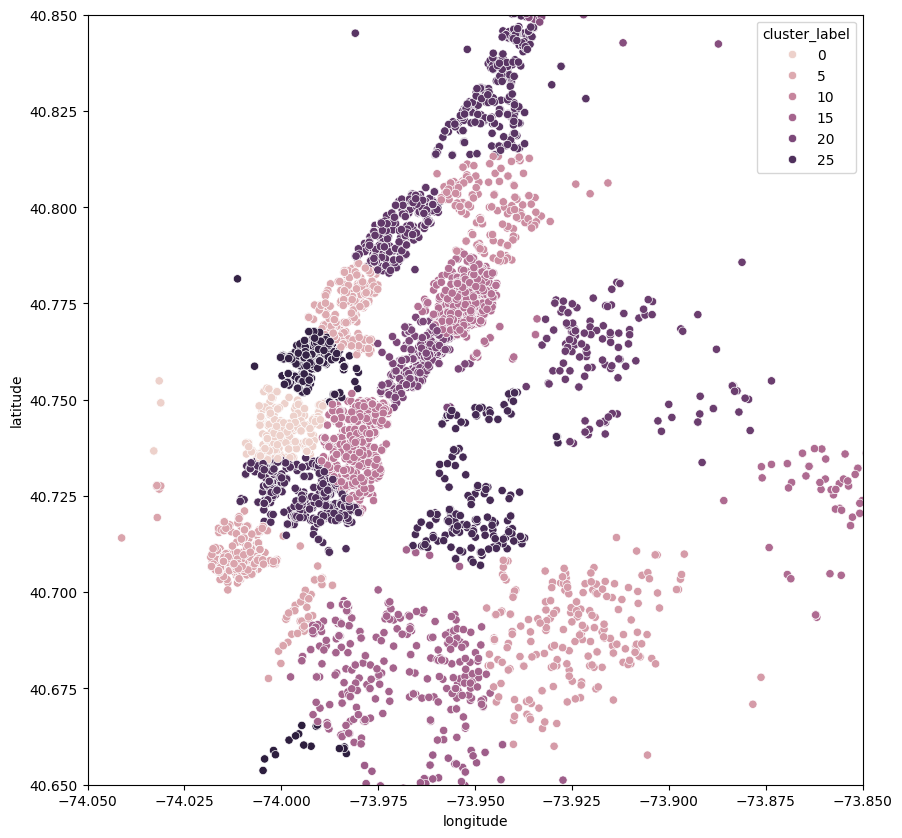

In [ ]:
import seaborn as sns
fig = plt.figure(figsize=(10, 10))
g = sns.scatterplot(
    x=test['longitude'],
    y=test['latitude'],
    hue=xtest['cluster_label']
)
g.set(xlim=(-74.05,-73.85))
g.set(ylim=(40.65,40.85))

In [ ]:
xtrain_norm = pd.DataFrame(scaler.fit_transform(xtrain))
xtest_norm = pd.DataFrame(scaler.transform(xtest))

lasso_model.fit(xtrain_norm, ytrain)

Lasso(random_state=21)

In [ ]:
feature_importance = pd.DataFrame()
feature_importance['name'] = xtrain.columns
feature_importance['imp'] = abs(lasso_model.coef_)
feature_importance = feature_importance.sort_values('imp')
feature_importance

,name,imp
2,CatsAllowed,0.000000
12,OutdoorSpace,0.360869
15,Balcony,13.943997
11,RoofDeck,48.478785
9,Pre-War,54.276748
16,SwimmingPool,56.044860
18,NewConstruction,57.201600
3,DogsAllowed,69.776620
6,NoFee,78.056592
19,Terrace,79.750639


In [ ]:
score_train=lasso_model.predict(xtrain_norm)
score_test=lasso_model.predict(xtest_norm)

result_MAE.append({'model' : 'Sklearn KMeans Lasso',
                   'train' : mean_absolute_error(ytrain, score_train),
                   'test' :  mean_absolute_error(ytest, score_test)
                  })


result_RMSE.append({'model' : 'Sklearn KMeans Lasso',
                   'train' : mean_squared_error(ytrain, score_train)**0.5,
                   'test' :  mean_squared_error(ytest, score_test)**0.5
                  })

result_r2.append({'model' : 'Sklearn KMeans Lasso',
                   'train' : r2_score(ytrain, score_train),
                   'test' :  r2_score(ytest, score_test)
                  })

display(pd.DataFrame(result_MAE))
display(pd.DataFrame(result_RMSE))
display(pd.DataFrame(result_r2))

,model,train,test
0,KMeans Lasso,646.901236,706.167728
1,Sklearn KMeans Lasso,646.438029,711.956557


,model,train,test
0,KMeans Lasso,905.754951,965.135392
1,Sklearn KMeans Lasso,904.002091,969.692988


,model,train,test
0,KMeans Lasso,0.594903,0.457838
1,Sklearn KMeans Lasso,0.596470,0.452706


## Task 4. DBScan

In [11]:
from math import dist

In [12]:
class DBSCAN:
  def __init__(self, eps: float = 0.5, minPts: int = 5):
    self.eps = eps
    self.minPts = minPts

  def fit_predict(self, X: np.ndarray):
    X = np.asarray(X)

    n = len(X)
    self.labels_ = [None] * n
    cluster_id = 0

    for id in range(n):
        if self.labels_[id] is not None:
          continue

        distances = np.linalg.norm(X - X[id], axis=1)
        neighbors = np.where(distances <= self.eps)[0].tolist()

        if len(neighbors) < self.minPts:
          self.labels_[id] = -1
          continue

        cluster_id += 1
        self.labels_[id] = cluster_id
        queue = neighbors

        queue_set = set(neighbors)

        while queue:
            j = queue.pop()
            queue_set.remove(j)

            if self.labels_[j] == -1:
                self.labels_[j] = cluster_id

            elif self.labels_[j] is None:
                self.labels_[j] = cluster_id

                dists = np.linalg.norm(X - X[j], axis=1)
                new_neighbors = np.where(dists <= self.eps)[0]

                if len(new_neighbors) >= self.minPts:
                    for k in new_neighbors:
                        if self.labels_[k] is None and k not in queue_set:
                            queue.append(k)
                            queue_set.add(k)

    return self.labels_

### Get optimal epsilon

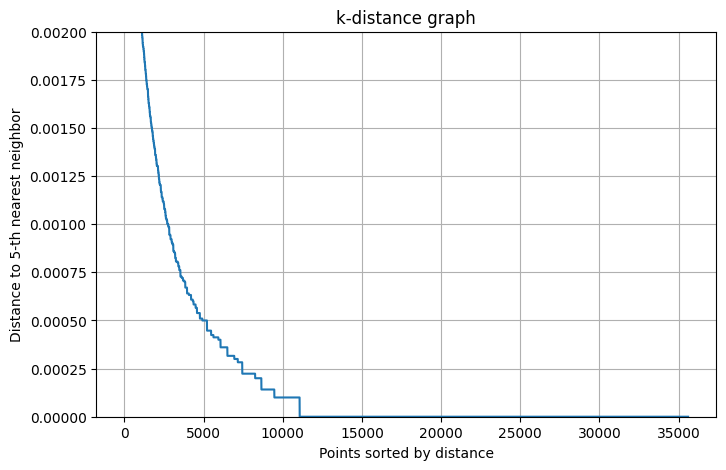

In [ ]:
from sklearn.neighbors import NearestNeighbors
def plot_k_distance_graph(X, k):
    X = np.asarray(X)

    nbrs = NearestNeighbors(n_neighbors=k).fit(X)
    distances, indices = nbrs.kneighbors(X)

    k_distances = distances[:, -1]

    k_distances = np.sort(k_distances)[::-1]

    plt.figure(figsize=(8, 5))
    plt.plot(k_distances)
    plt.ylim(0, 0.002)
    plt.xlabel("Points sorted by distance")
    plt.ylabel(f"Distance to {k}-th nearest neighbor")
    plt.title("k-distance graph")
    plt.grid(True)
    plt.show()

    return k_distances

k_distances = plot_k_distance_graph(train[['latitude', 'longitude']], k=5)

In [13]:
dbscan = DBSCAN(eps=0.001, minPts=5)

_start = time.perf_counter()
xtrain['cluster_label'] = dbscan.fit_predict(train[['latitude', 'longitude']])
_elapsed = time.perf_counter() - _start
timing_results.append({'algorithm': 'DBSCAN Lasso', 'n_samples': train.shape[0], 'time_sec': _elapsed})
print(f"Custom DBSCAN fit_predict time: {_elapsed:.4f} sec")

xtest['cluster_label'] = dbscan.fit_predict(test[['latitude', 'longitude']])

Custom DBSCAN fit_predict time: 7.5150 sec


### Silhouette score and Distortion.

In [22]:
def get_distortion(X, labels):
    X = np.asarray(X)
    labels = np.asarray(labels)

    unique_labels = np.unique(labels)
    unique_labels = unique_labels[unique_labels != -1]

    centers = {}
    total_distortion = 0.0

    for label in unique_labels:
        points = X[labels == label]

        dist_matrix = cdist(points, points)
        total_dist = dist_matrix.sum(axis=1)

        centroid_idx = np.argmin(total_dist)
        centers[label] = points[centroid_idx]

        dist_to_centroid = dist_matrix[:, centroid_idx]
        total_distortion += np.sum(dist_to_centroid ** 2)

    return centers, total_distortion

In [ ]:
print(f"Silhouette score: {silhouette_score(train[['latitude', 'longitude']], xtrain['cluster_label'])}")

centroids, distortion = get_distortion(train[['latitude', 'longitude']], xtrain['cluster_label'])

print(f"Distortion: {distortion}")

Silhouette score: -0.07295389945084743
Distortion: 1.2893333699999552


### Plot

[(40.65, 40.85)]

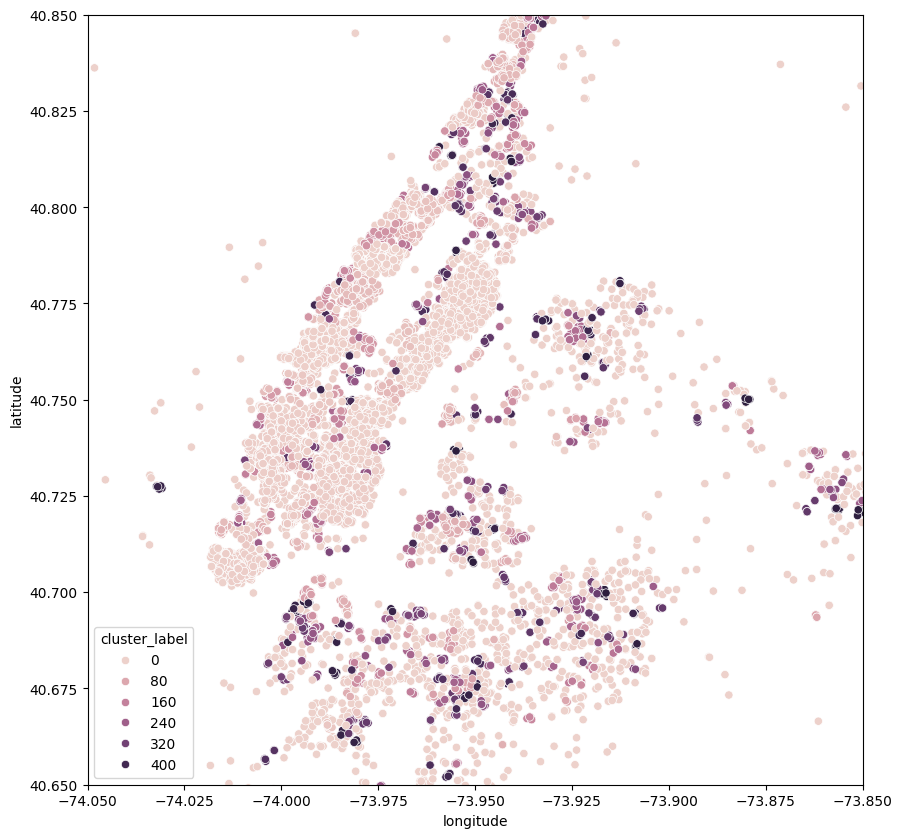

In [ ]:
import seaborn as sns
fig = plt.figure(figsize=(10, 10))
g = sns.scatterplot(
    x=train['longitude'],
    y=train['latitude'],
    hue=xtrain['cluster_label']
)
g.set(xlim=(-74.05,-73.85))
g.set(ylim=(40.65,40.85))

[(40.65, 40.85)]

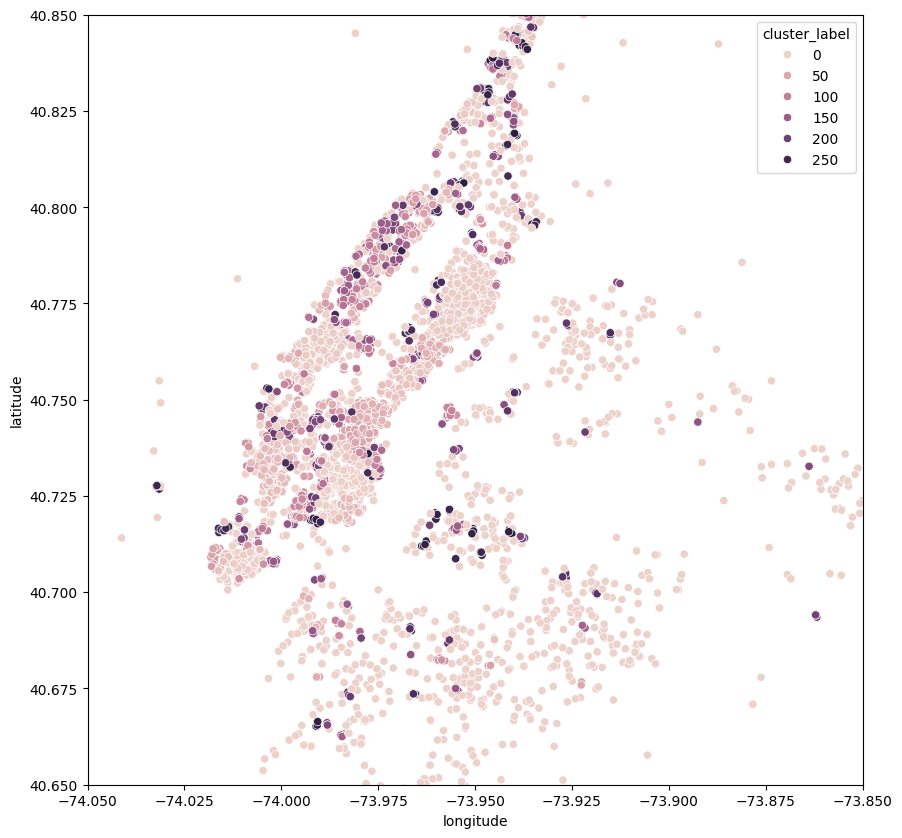

In [ ]:
import seaborn as sns
fig = plt.figure(figsize=(10, 10))
g = sns.scatterplot(
    x=test['longitude'],
    y=test['latitude'],
    hue=xtest['cluster_label']
)
g.set(xlim=(-74.05,-73.85))
g.set(ylim=(40.65,40.85))

### Lasso Regression

In [ ]:
lasso_model, feature_importance, xtrain_norm, xtest_norm = fit_lasso_and_get_feature_importance(xtrain, ytrain, xtest)


feature_importance

,name,imp
2,CatsAllowed,0.000000
15,Balcony,3.751563
12,OutdoorSpace,7.891171
16,SwimmingPool,30.093377
9,Pre-War,54.093504
18,NewConstruction,57.458340
11,RoofDeck,69.076484
6,NoFee,76.757610
3,DogsAllowed,80.576959
19,Terrace,80.657711


In [ ]:
dict_MAE, dict_RMSE, dict_r2 = get_metrics(lasso_model, xtrain_norm,
                                                 ytrain, xtest_norm, ytest, 'DBSCAN Lasso')

In [ ]:
def save_metrics(dict_MAE, dict_RMSE, dict_r2):
  result_MAE = pd.read_csv('data/result_MAE.csv')
  result_RMSE = pd.read_csv('data/result_RMSE.csv')
  result_r2 = pd.read_csv('data/result_r2.csv')

  result_MAE = pd.concat([result_MAE, pd.DataFrame([dict_MAE])], axis=0)

  result_RMSE = pd.concat([result_RMSE, pd.DataFrame([dict_RMSE])], axis=0)

  result_r2 = pd.concat([result_r2, pd.DataFrame([dict_r2])], axis=0)

  result_MAE.to_csv('data/result_MAE.csv', index=False)
  result_RMSE.to_csv('data/result_RMSE.csv', index=False)
  result_r2.to_csv('data/result_r2.csv', index=False)


def display_metrics():
  result_MAE = pd.read_csv('data/result_MAE.csv')
  result_RMSE = pd.read_csv('data/result_RMSE.csv')
  result_r2 = pd.read_csv('data/result_r2.csv')

  print('MAE')
  display(result_MAE)
  print('RMSE')
  display(result_RMSE)
  print('r2')
  display(result_r2)

In [ ]:
display_metrics()

MAE


,model,train,test
0,KMeans Lasso,646.901236,706.167728
1,Sklearn KMeans Lasso,646.438029,711.956557
2,DBSCAN Lasso,646.062722,718.027120


RMSE


,model,train,test
0,KMeans Lasso,905.754951,965.135392
1,Sklearn KMeans Lasso,904.002091,969.692988
2,DBSCAN Lasso,903.301199,980.033843


r2


,model,train,test
0,KMeans Lasso,0.594903,0.457838
1,Sklearn KMeans Lasso,0.596470,0.452706
2,DBSCAN Lasso,0.597095,0.440971


### Sklearn comparing

In [14]:
sklearn_dbscan = cluster.DBSCAN(eps=0.001, min_samples=5)

_start = time.perf_counter()
xtrain['cluster_label'] = sklearn_dbscan.fit_predict(train[['latitude', 'longitude']])
_elapsed = time.perf_counter() - _start
timing_results.append({'algorithm': 'Sklearn DBSCAN Lasso', 'n_samples': train.shape[0], 'time_sec': _elapsed})
print(f"Sklearn DBSCAN fit_predict time: {_elapsed:.4f} sec")

xtest['cluster_label'] = sklearn_dbscan.fit_predict(test[['latitude', 'longitude']])

Sklearn DBSCAN fit_predict time: 0.3904 sec


In [ ]:
print(f"Silhouette score: {silhouette_score(train[['latitude', 'longitude']], xtrain['cluster_label'])}")

centroids, distortion = get_distortion(train[['latitude', 'longitude']], xtrain['cluster_label'])

print(f"Distortion: {distortion}")

Silhouette score: -0.07246478181658814
Distortion: 1.2893607899999555


[(40.65, 40.85)]

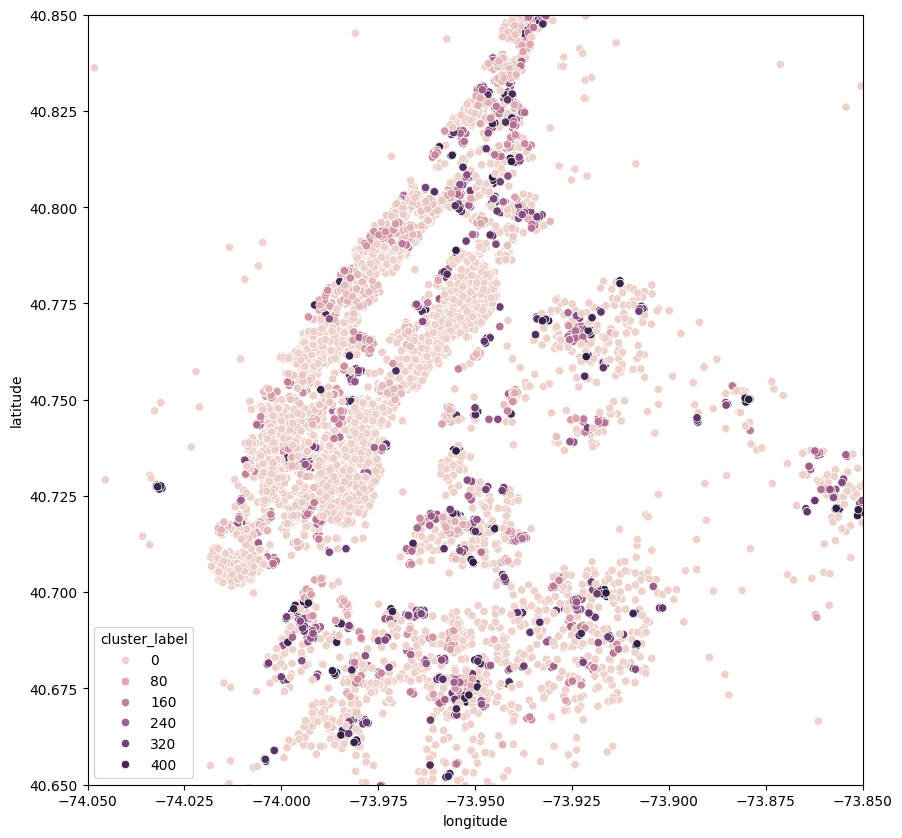

In [ ]:
import seaborn as sns
fig = plt.figure(figsize=(10, 10))
g = sns.scatterplot(
    x=train['longitude'],
    y=train['latitude'],
    hue=xtrain['cluster_label']
)
g.set(xlim=(-74.05,-73.85))
g.set(ylim=(40.65,40.85))

[(40.65, 40.85)]

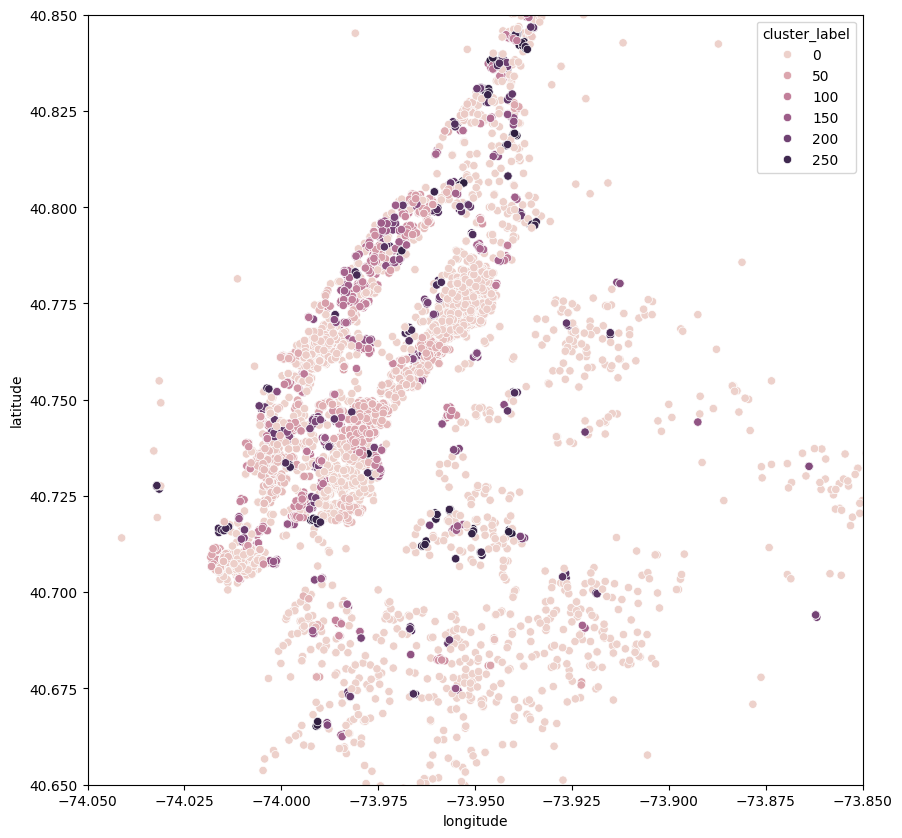

In [ ]:
import seaborn as sns
fig = plt.figure(figsize=(10, 10))
g = sns.scatterplot(
    x=test['longitude'],
    y=test['latitude'],
    hue=xtest['cluster_label']
)
g.set(xlim=(-74.05,-73.85))
g.set(ylim=(40.65,40.85))

In [ ]:
lasso_model, feature_importance, xtrain_norm, xtest_norm = fit_lasso_and_get_feature_importance(xtrain, ytrain, xtest)

feature_importance

,name,imp
2,CatsAllowed,0.000000
15,Balcony,3.793040
12,OutdoorSpace,7.919479
16,SwimmingPool,30.094933
9,Pre-War,54.226987
18,NewConstruction,57.225805
11,RoofDeck,69.142140
6,NoFee,76.677294
3,DogsAllowed,80.552912
19,Terrace,80.652292


In [ ]:
dict_MAE, dict_RMSE, dict_r2 = get_metrics(lasso_model, xtrain_norm, ytrain,
                                           xtest_norm, ytest,
                                           'Sklearn DBSCAN Lasso')
save_metrics(dict_MAE, dict_RMSE, dict_r2)

display_metrics()

MAE


,model,train,test
0,KMeans Lasso,646.901236,706.167728
1,Sklearn KMeans Lasso,646.438029,711.956557
2,DBSCAN Lasso,646.062722,718.027120
3,Sklearn DBSCAN Lasso,645.960104,718.017789


RMSE


,model,train,test
0,KMeans Lasso,905.754951,965.135392
1,Sklearn KMeans Lasso,904.002091,969.692988
2,DBSCAN Lasso,903.301199,980.033843
3,Sklearn DBSCAN Lasso,903.201803,980.132894


r2


,model,train,test
0,KMeans Lasso,0.594903,0.457838
1,Sklearn KMeans Lasso,0.596470,0.452706
2,DBSCAN Lasso,0.597095,0.440971
3,Sklearn DBSCAN Lasso,0.597184,0.440858


## Task 5. AgglomerativeClustering algorithm

### Fit and predict

In [15]:
sklearn_ac = cluster.AgglomerativeClustering(n_clusters=30)

_start = time.perf_counter()
xtrain['cluster_label'] = sklearn_ac.fit_predict(train[['latitude', 'longitude']])
_elapsed = time.perf_counter() - _start
timing_results.append({'algorithm': 'Sklearn AgglomerativeClustering', 'n_samples': train.shape[0], 'time_sec': _elapsed})
print(f"Sklearn AgglomerativeClustering fit_predict time: {_elapsed:.4f} sec")

xtest['cluster_label'] = sklearn_ac.fit_predict(test[['latitude', 'longitude']])

Sklearn AgglomerativeClustering fit_predict time: 81.8748 sec


### Silhouette score and Distortion.

In [ ]:
print(f"Silhouette score: {silhouette_score(train[['latitude', 'longitude']], xtrain['cluster_label'])}")

centroids, distortion = get_distortion(train[['latitude', 'longitude']], xtrain['cluster_label'])

print(f"Distortion: {distortion}")

Silhouette score: 0.43409942630552195
Distortion: 4.848946580000058


### Plot

[(40.65, 40.85)]

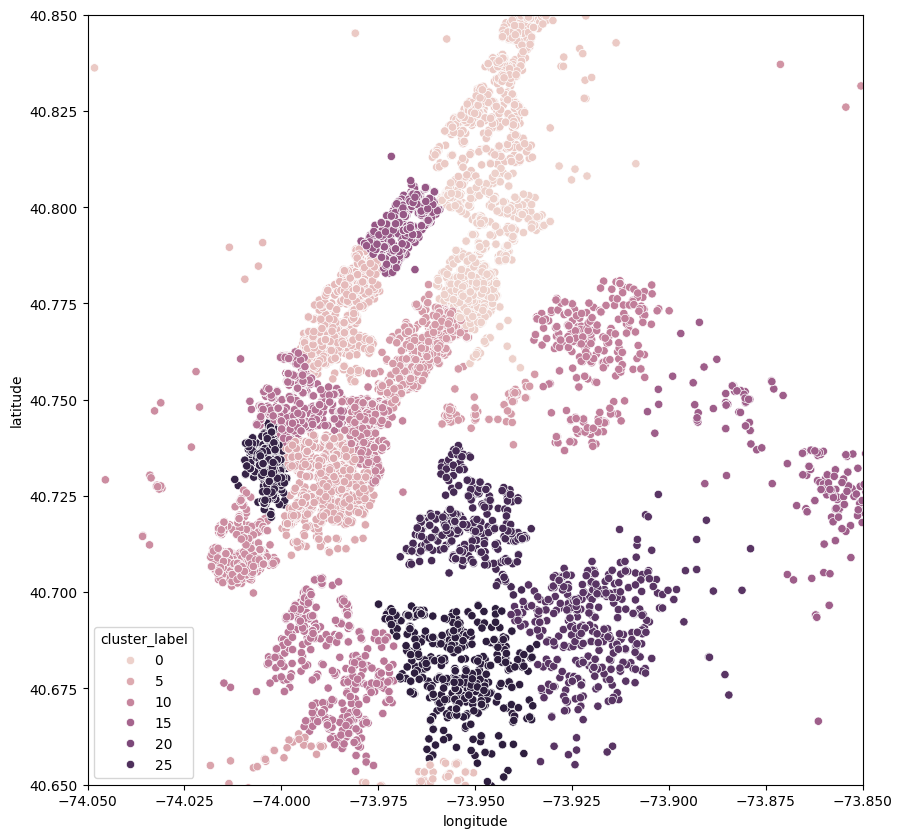

In [ ]:
import seaborn as sns
fig = plt.figure(figsize=(10, 10))
g = sns.scatterplot(
    x=train['longitude'],
    y=train['latitude'],
    hue=xtrain['cluster_label']
)
g.set(xlim=(-74.05,-73.85))
g.set(ylim=(40.65,40.85))

[(40.65, 40.85)]

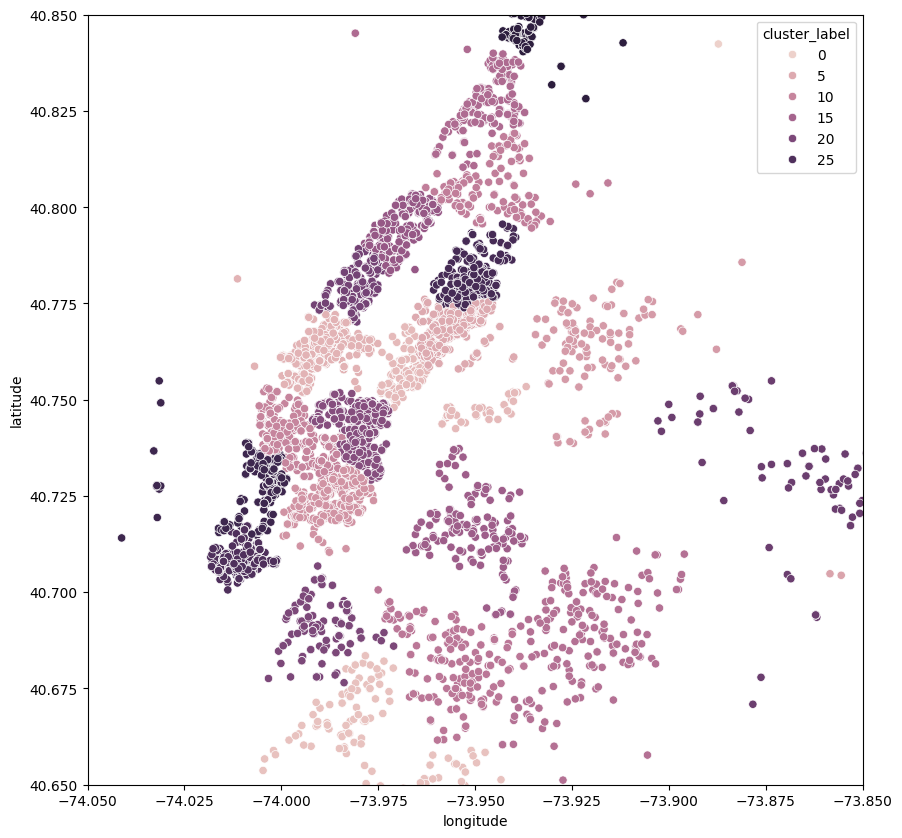

In [ ]:
import seaborn as sns
fig = plt.figure(figsize=(10, 10))
g = sns.scatterplot(
    x=test['longitude'],
    y=test['latitude'],
    hue=xtest['cluster_label']
)
g.set(xlim=(-74.05,-73.85))
g.set(ylim=(40.65,40.85))

### Importance

In [ ]:
lasso_model, feature_importance, xtrain_norm, xtest_norm = fit_lasso_and_get_feature_importance(xtrain, ytrain, xtest)

feature_importance

,name,imp
2,CatsAllowed,0.000000
15,Balcony,0.000000
12,OutdoorSpace,8.979672
16,SwimmingPool,43.702449
9,Pre-War,56.065577
11,RoofDeck,68.569443
3,DogsAllowed,69.415386
19,Terrace,78.543992
6,NoFee,86.714344
13,DiningRoom,92.613458


### Metrics

In [ ]:
dict_MAE, dict_RMSE, dict_r2 = get_metrics(lasso_model, xtrain_norm, ytrain,
                                           xtest_norm, ytest,
                                           'Sklearn AgglomerativeClustering Lasso')
save_metrics(dict_MAE, dict_RMSE, dict_r2)

display_metrics()

MAE


,model,train,test
0,KMeans Lasso,646.901236,706.167728
1,Sklearn KMeans Lasso,646.438029,711.956557
2,DBSCAN Lasso,646.062722,718.027120
3,Sklearn DBSCAN Lasso,645.960104,718.017789
4,Sklearn AgglomerativeClustering Lasso,646.576290,715.866742


RMSE


,model,train,test
0,KMeans Lasso,905.754951,965.135392
1,Sklearn KMeans Lasso,904.002091,969.692988
2,DBSCAN Lasso,903.301199,980.033843
3,Sklearn DBSCAN Lasso,903.201803,980.132894
4,Sklearn AgglomerativeClustering Lasso,905.465694,966.015043


r2


,model,train,test
0,KMeans Lasso,0.594903,0.457838
1,Sklearn KMeans Lasso,0.596470,0.452706
2,DBSCAN Lasso,0.597095,0.440971
3,Sklearn DBSCAN Lasso,0.597184,0.440858
4,Sklearn AgglomerativeClustering Lasso,0.595162,0.456850


## Task 6. Gaussian Mixture algorithm

### Fit and predict

In [16]:
sklearn_gmm = GaussianMixture(n_components=30, random_state=21)

_start = time.perf_counter()
xtrain['cluster_label'] = sklearn_gmm.fit_predict(train[['latitude', 'longitude']])
_elapsed = time.perf_counter() - _start
timing_results.append({'algorithm': 'Sklearn GaussianMixture', 'n_samples': train.shape[0], 'time_sec': _elapsed})
print(f"Sklearn GaussianMixture fit_predict time: {_elapsed:.4f} sec")

xtest['cluster_label'] = sklearn_gmm.fit_predict(test[['latitude', 'longitude']])

Sklearn GaussianMixture fit_predict time: 5.3746 sec


### Silhouette score and Distortion.

In [ ]:
print(f"Silhouette score: {silhouette_score(train[['latitude', 'longitude']], xtrain['cluster_label'])}")

centroids, distortion = get_distortion(train[['latitude', 'longitude']], xtrain['cluster_label'])

print(f"Distortion: {distortion}")

Silhouette score: 0.3918704633425947
Distortion: 8.636345320000023


### Plot

[(40.65, 40.85)]

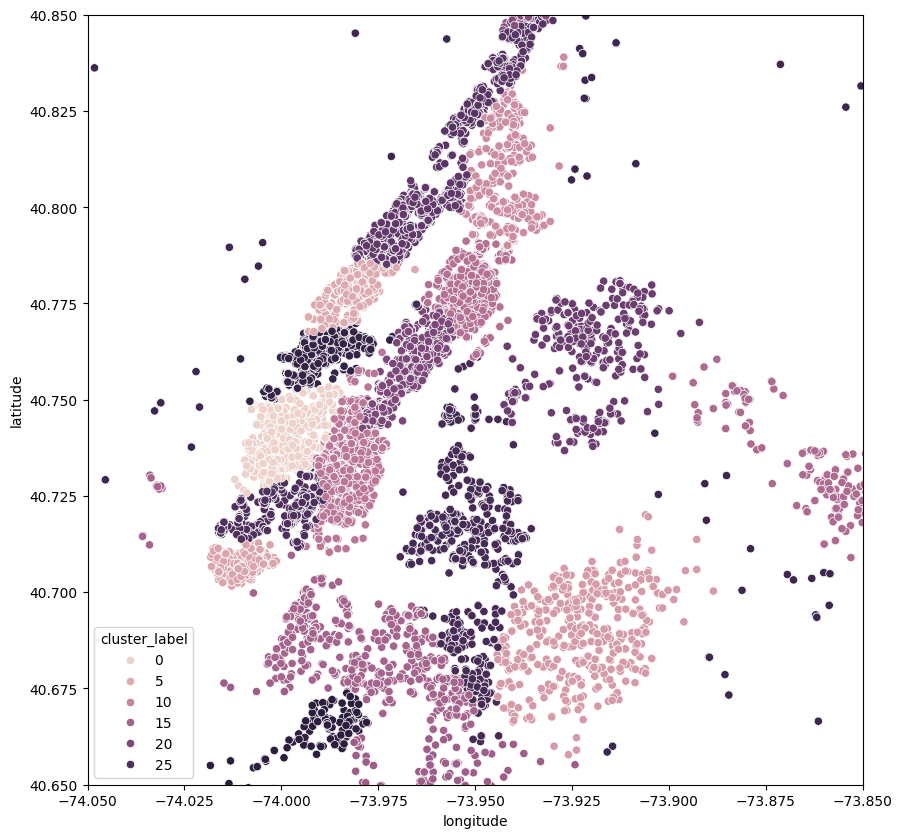

In [ ]:
fig = plt.figure(figsize=(10, 10))
g = sns.scatterplot(
    x=train['longitude'],
    y=train['latitude'],
    hue=xtrain['cluster_label']
)
g.set(xlim=(-74.05,-73.85))
g.set(ylim=(40.65,40.85))

[(40.65, 40.85)]

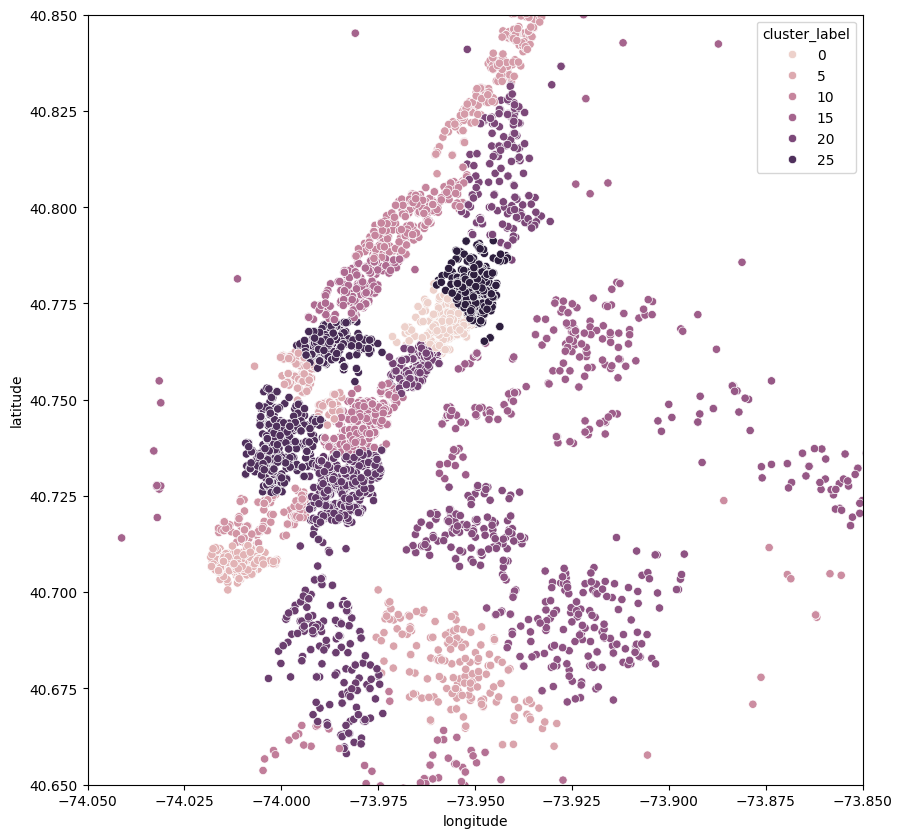

In [ ]:
fig = plt.figure(figsize=(10, 10))
g = sns.scatterplot(
    x=test['longitude'],
    y=test['latitude'],
    hue=xtest['cluster_label']
)
g.set(xlim=(-74.05,-73.85))
g.set(ylim=(40.65,40.85))

### Feature importance

In [ ]:
lasso_model, feature_importance, xtrain_norm, xtest_norm = fit_lasso_and_get_feature_importance(xtrain, ytrain, xtest)

feature_importance

,name,imp
2,CatsAllowed,0.000000
12,OutdoorSpace,2.450683
15,Balcony,21.287254
18,NewConstruction,43.411189
11,RoofDeck,52.557017
9,Pre-War,59.559303
16,SwimmingPool,59.765144
3,DogsAllowed,70.735513
6,NoFee,71.686353
19,Terrace,74.446973


### Metrics

In [ ]:
dict_MAE, dict_RMSE, dict_r2 = get_metrics(lasso_model, xtrain_norm, ytrain,
                                           xtest_norm, ytest,
                                           'Sklearn Gaussian Mixture Lasso')
save_metrics(dict_MAE, dict_RMSE, dict_r2)

display_metrics()

MAE


,model,train,test
0,KMeans Lasso,646.901236,706.167728
1,Sklearn KMeans Lasso,646.438029,711.956557
2,DBSCAN Lasso,646.062722,718.027120
3,Sklearn DBSCAN Lasso,645.960104,718.017789
4,Sklearn AgglomerativeClustering Lasso,646.576290,715.866742
5,Sklearn Gaussian Mixture Lasso,641.580287,727.931238


RMSE


,model,train,test
0,KMeans Lasso,905.754951,965.135392
1,Sklearn KMeans Lasso,904.002091,969.692988
2,DBSCAN Lasso,903.301199,980.033843
3,Sklearn DBSCAN Lasso,903.201803,980.132894
4,Sklearn AgglomerativeClustering Lasso,905.465694,966.015043
5,Sklearn Gaussian Mixture Lasso,897.745792,992.321257


r2


,model,train,test
0,KMeans Lasso,0.594903,0.457838
1,Sklearn KMeans Lasso,0.596470,0.452706
2,DBSCAN Lasso,0.597095,0.440971
3,Sklearn DBSCAN Lasso,0.597184,0.440858
4,Sklearn AgglomerativeClustering Lasso,0.595162,0.456850
5,Sklearn Gaussian Mixture Lasso,0.602036,0.426865


## Task 7. New set of features for clustering

In [18]:
new_features = ['bedrooms', 'bathrooms', 'interest_level']

### K-Means

In [23]:
sklearn_kmeans = cluster.KMeans(n_clusters=30, random_state=21)

_start = time.perf_counter()
sklearn_kmeans.fit(xtrain[new_features])
_elapsed = time.perf_counter() - _start
timing_results.append({'algorithm': 'Sklearn KMeans New Features Lasso', 'n_samples': xtrain.shape[0], 'time_sec': _elapsed})
print(f"Sklearn KMeans New Features fit time: {_elapsed:.4f} sec")


xtrain['cluster_label'] = sklearn_kmeans.predict(xtrain[new_features])
xtest['cluster_label'] = sklearn_kmeans.predict(xtest[new_features])

print(f"Silhouette score: {silhouette_score(xtrain[new_features], xtrain['cluster_label'])}")

centroids, distortion = get_distortion(xtrain[new_features], xtrain['cluster_label'])

print(f"Distortion: {distortion}")

Sklearn KMeans New Features fit time: 0.0695 sec
Silhouette score: 0.9690129517395322
Distortion: 517.25


In [ ]:
lasso_model, feature_importance, xtrain_norm, xtest_norm = fit_lasso_and_get_feature_importance(xtrain, ytrain, xtest)

feature_importance[:-6:-1]

,name,imp
20,bathrooms,11489.773611
21,bedrooms,3666.333005
22,interest_level,891.991971
4,Doorman,530.850957
23,cluster_label,458.142032


In [ ]:
dict_MAE, dict_RMSE, dict_r2 = get_metrics(lasso_model, xtrain_norm, ytrain,
                                           xtest_norm, ytest,
                                           'Sklearn K-means New Features Lasso')
save_metrics(dict_MAE, dict_RMSE, dict_r2)

### DBSCAN

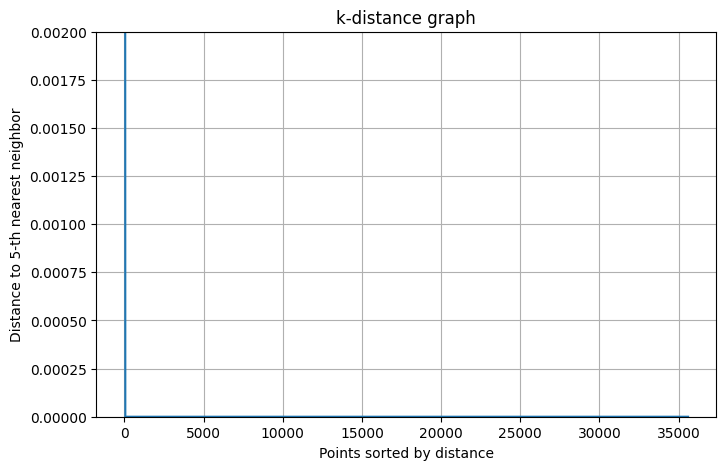

In [ ]:
k_distances = plot_k_distance_graph(MinMaxScaler().fit_transform(train[new_features]), k=5)

In [20]:
dbscan = cluster.DBSCAN(eps=0.001, min_samples=5)
scaler = MinMaxScaler()

_start = time.perf_counter()
xtrain['cluster_label'] = dbscan.fit_predict(scaler.fit_transform(train[new_features]))
_elapsed = time.perf_counter() - _start
timing_results.append({'algorithm': 'Sklearn DBSCAN (new features)', 'n_samples': train.shape[0], 'time_sec': _elapsed})
print(f"Sklearn DBSCAN (new features) fit_predict time: {_elapsed:.4f} sec")

xtest['cluster_label'] = dbscan.fit_predict(scaler.transform(test[new_features]))

Sklearn DBSCAN (new features) fit_predict time: 2.0173 sec


In [ ]:
print(f"Silhouette score: {silhouette_score(xtrain[new_features], xtrain['cluster_label'])}")

centroids, distortion = get_distortion(xtrain[new_features], xtrain['cluster_label'])

print(f"Distortion: {distortion}")

Silhouette score: 0.9976610871211183
Distortion: 0.0


In [ ]:
lasso_model, feature_importance, xtrain_norm, xtest_norm = fit_lasso_and_get_feature_importance(xtrain, ytrain, xtest)

dict_MAE, dict_RMSE, dict_r2 = get_metrics(lasso_model, xtrain_norm, ytrain,
                                           xtest_norm, ytest,
                                           'Sklearn DBSCAN New Features Lasso')
save_metrics(dict_MAE, dict_RMSE, dict_r2)

### AgglomerativeClustering algorithm

In [24]:
sklearn_ac = cluster.AgglomerativeClustering(n_clusters=30)

_start = time.perf_counter()
xtrain['cluster_label'] = sklearn_ac.fit_predict(train[new_features])
_elapsed = time.perf_counter() - _start
timing_results.append({'algorithm': 'Sklearn AgglomerativeClustering New Features Lasso', 'n_samples': train.shape[0], 'time_sec': _elapsed})
print(f"Sklearn AgglomerativeClustering (new features) fit_predict time: {_elapsed:.4f} sec")

xtest['cluster_label'] = sklearn_ac.fit_predict(test[new_features])

print(f"Silhouette score: {silhouette_score(xtrain[new_features], xtrain['cluster_label'])}")

centroids, distortion = get_distortion(xtrain[new_features], xtrain['cluster_label'])

print(f"Distortion: {distortion}")

Sklearn AgglomerativeClustering (new features) fit_predict time: 38.5946 sec
Silhouette score: 0.9651998215069008
Distortion: 601.25


In [ ]:
lasso_model, feature_importance, xtrain_norm, xtest_norm = fit_lasso_and_get_feature_importance(xtrain, ytrain, xtest)

dict_MAE, dict_RMSE, dict_r2 = get_metrics(lasso_model, xtrain_norm, ytrain,
                                           xtest_norm, ytest,
                                           'Sklearn AgglomerativeClustering New Features Lasso')
save_metrics(dict_MAE, dict_RMSE, dict_r2)

### Gaussian Mixture algorithm

In [25]:
sklearn_gmm = GaussianMixture(n_components=30, random_state=21)

_start = time.perf_counter()
xtrain['cluster_label'] = sklearn_gmm.fit_predict(train[new_features])
_elapsed = time.perf_counter() - _start
timing_results.append({'algorithm': 'Sklearn GaussianMixture New Features Lasso', 'n_samples': train.shape[0], 'time_sec': _elapsed})
print(f"Sklearn GaussianMixture (new features) fit_predict time: {_elapsed:.4f} sec")

xtest['cluster_label'] = sklearn_gmm.fit_predict(test[new_features])

print(f"Silhouette score: {silhouette_score(xtrain[new_features], xtrain['cluster_label'])}")

centroids, distortion = get_distortion(xtrain[new_features], xtrain['cluster_label'])

print(f"Distortion: {distortion}")

Sklearn GaussianMixture (new features) fit_predict time: 3.2348 sec
Silhouette score: 0.9659020331937841
Distortion: 1814.75


In [ ]:
lasso_model, feature_importance, xtrain_norm, xtest_norm = fit_lasso_and_get_feature_importance(xtrain, ytrain, xtest)

dict_MAE, dict_RMSE, dict_r2 = get_metrics(lasso_model, xtrain_norm, ytrain,
                                           xtest_norm, ytest,
                                           'Sklearn Gaussian Mixture New Features Lasso')
save_metrics(dict_MAE, dict_RMSE, dict_r2)

## Task 8.

In [ ]:
display_metrics()

MAE


,model,train,test
0,KMeans Lasso,646.901236,706.167728
1,Sklearn KMeans Lasso,646.438029,711.956557
2,DBSCAN Lasso,646.062722,718.027120
3,Sklearn DBSCAN Lasso,645.960104,718.017789
4,Sklearn AgglomerativeClustering Lasso,646.576290,715.866742
5,Sklearn Gaussian Mixture Lasso,641.580287,727.931238
6,Sklearn K-means New Features Lasso,648.687038,708.821459
7,Sklearn DBSCAN New Features Lasso,650.688294,707.070679
8,Sklearn AgglomerativeClustering New Features L...,650.409585,697.880895
9,Sklearn Gaussian Mixture New Features Lasso,647.793567,710.181621


RMSE


,model,train,test
0,KMeans Lasso,905.754951,965.135392
1,Sklearn KMeans Lasso,904.002091,969.692988
2,DBSCAN Lasso,903.301199,980.033843
3,Sklearn DBSCAN Lasso,903.201803,980.132894
4,Sklearn AgglomerativeClustering Lasso,905.465694,966.015043
5,Sklearn Gaussian Mixture Lasso,897.745792,992.321257
6,Sklearn K-means New Features Lasso,906.703325,973.451934
7,Sklearn DBSCAN New Features Lasso,908.118771,963.901165
8,Sklearn AgglomerativeClustering New Features L...,908.684257,960.555468
9,Sklearn Gaussian Mixture New Features Lasso,905.448498,966.526429


r2


,model,train,test
0,KMeans Lasso,0.594903,0.457838
1,Sklearn KMeans Lasso,0.596470,0.452706
2,DBSCAN Lasso,0.597095,0.440971
3,Sklearn DBSCAN Lasso,0.597184,0.440858
4,Sklearn AgglomerativeClustering Lasso,0.595162,0.456850
5,Sklearn Gaussian Mixture Lasso,0.602036,0.426865
6,Sklearn K-means New Features Lasso,0.594054,0.448455
7,Sklearn DBSCAN New Features Lasso,0.592786,0.459224
8,Sklearn AgglomerativeClustering New Features L...,0.592279,0.462972
9,Sklearn Gaussian Mixture New Features Lasso,0.595177,0.456274


In [31]:
timing_df = pd.DataFrame(timing_results)
timing_df = timing_df.sort_values('time_sec', ascending=False).reset_index(drop=True)
timing_df

,algorithm,n_samples,time_sec
0,Sklearn AgglomerativeClustering,35599,81.874840
1,KMeans Lasso,35599,74.768802
2,Sklearn AgglomerativeClustering New Features L...,35599,38.594591
3,DBSCAN Lasso,35599,7.514981
4,Sklearn GaussianMixture,35599,5.374610
5,Sklearn GaussianMixture New Features Lasso,35599,3.234816
6,Sklearn DBSCAN (new features),35599,2.017275
7,Sklearn DBSCAN Lasso,35599,0.390437
8,Sklearn KMeans (lat/long),35599,0.118869
9,Sklearn KMeans New Features Lasso,35599,0.069461


| Алгоритм | Временная сложность | Пояснение |
|---|---|---|
| Custom KMeans | O(n · k · d · i) | n — число точек, k — число кластеров, d — размерность, i — число итераций до сходимости; на каждой итерации считаются расстояния от всех точек до всех центроидов |
| Sklearn KMeans | O(n · k · d · i) | тот же алгоритм Ллойда/Элкана, тот же порядок сложности, что и у самописной версии |
| Custom DBSCAN | O(n² · d) | наивный поиск соседей полным перебором (`np.linalg.norm(X - X[id])` для каждой точки), без пространственного индекса |
| Sklearn DBSCAN | O(n log n · d) в среднем, O(n² · d) в худшем случае | использует KD-Tree / Ball-Tree по умолчанию для поиска соседей |
| Sklearn AgglomerativeClustering | O(n² · log n) | строит и хранит полную матрицу попарных расстояний между всеми точками |
| Sklearn GaussianMixture (EM) | O(n · k · d² · i) для full covariance, O(n · k · d · i) для diagonal covariance | на каждой EM-итерации считаются вероятности принадлежности каждой точки каждому гауссиану |